# Daily-Return LSTM — Walk-Forward Notebook  
 *AAPL example – 20 % validation inside each fold, final 200-day hold-out*

 **Contents**
 1. Imports & helper classes  
 2. Data fetch → CSV cache  
 3. Indicator engineering & raw visualisation  
 4. Window builder + Dataset + train/val/test split chart  
 5. Walk-forward training loop with early-stopping  
 6. Fold metrics + prediction vs actual plots  
 7. Save best model, scalers & feature order  
 8. Reload demo from a fresh Python session

In [1]:
import os
import requests
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.optim as optim
import torch
import torch.nn as nn
import torch.optim as optim
from datetime import datetime, timedelta
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from collections.abc import Sized
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from pandas.tseries.offsets import QuarterEnd
from typing import Any
import pyodbc


WINDOW_SIZE  = 15          # sliding window length
EPOCHS       = 60
BATCH        = 32
HIDDEN_DIM   = 100
DROPOUT      = 0.5
LR           = 1e-3
WD           = 5e-4
PATIENCE     = 8
N_SPLITS     = 5
TEST_SIZE    = 100         
TARGET       = "Return_1D"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [8]:
import pyodbc
import pandas as pd

ODBC_CONN = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=capstone-database-server.database.windows.net,1433;"
    "DATABASE=writedatabasesilverlayer;"
    "UID=capstonedioxieteam;"
    "PWD=Connhenbeo1@;"
    "Encrypt=yes;TrustServerCertificate=no;Connection Timeout=30;"
)

try:
    cn = pyodbc.connect(ODBC_CONN)
    print("Connected to SQL Server!")

    sql = """
    SELECT TOP (2250)
      [Date]           AS date,
      [Open]           AS Open,
      [High]           AS high,
      [Low]            AS low,
      [Close]          AS close,
      [Volume]         AS volume
    FROM Silver.Historical_Prices
    WHERE Stock_Symbol = ?
    ORDER BY [Date] DESC
    """
    df = pd.read_sql(sql, cn, params=["AAPL"])
    cn.close()

    # reverse order so oldest → newest
    df = df.sort_values("date").reset_index(drop=True)
    # rename back to lowercase open
    df = df.rename(columns={"open_price": "open"})

    print("\n--- AAPL sample ---")
    print(df.head())

except Exception as e:
    print(" ODBC error:", e)


Connected to SQL Server!
 ODBC error: Execution failed on sql '
    SELECT TOP (2250)
      [Date]           AS date,
      [Open]           AS Open,
      [High]           AS high,
      [Low]            AS low,
      [Close]          AS close,
      [Volume]         AS volume
    FROM Silver.Historical_Prices
    WHERE Stock_Symbol = ?
    ORDER BY [Date] DESC
    ': ('42000', "[42000] [Microsoft][ODBC Driver 18 for SQL Server][SQL Server]Incorrect syntax near the keyword 'Open'. (156) (SQLExecDirectW); [42000] [Microsoft][ODBC Driver 18 for SQL Server][SQL Server]Statement(s) could not be prepared. (8180)")


C:\Users\Gautam\AppData\Local\Temp\ipykernel_12544\1863521105.py:29: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, cn, params=["AAPL"])


In [2]:
API_KEY = "JcmfjzcBwo5HGSiM5Yib7ylfG2PmSNzc"
TICKER  = "AAPL" 

def fetch_all_history_fmp(ticker: str, api_key: str) -> pd.DataFrame:
    all_chunks = []
    to_date = datetime.today().date()
    chunk_size = 1500

    while True:
        from_date = to_date - timedelta(days=int(chunk_size*1.5))
        url = (
            f"https://financialmodelingprep.com/api/v3/historical-price-full/{ticker}"
            f"?from={from_date:%Y-%m-%d}&to={to_date:%Y-%m-%d}"
            f"&apikey={api_key}"
        )
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        data = resp.json().get("historical", [])
        if not data:
            break

        df_chunk = pd.DataFrame(data)[["date","open","high","low","close","volume"]]
        df_chunk["date"] = pd.to_datetime(df_chunk["date"])
        all_chunks.append(df_chunk)

        earliest = df_chunk["date"].min().date()
        if (to_date - earliest).days < 2:
            break
        to_date = earliest - timedelta(days=1)

    df = pd.concat(all_chunks, ignore_index=True)
    df = df.drop_duplicates(subset="date").sort_values("date").reset_index(drop=True)

    df["Return_3D"]     = df["close"].pct_change(periods=3).shift(-3)
    df["Return_1D"]     = df["close"].pct_change()
    df["Volatility_3D"] = df["Return_1D"].rolling(window=3).std()

    return df.dropna(subset=["Return_3D","Volatility_3D"]).reset_index(drop=True)

# ODBC parameters
ODBC_CONN_STR = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=capstone-database-server.database.windows.net,1433;"
    "DATABASE=writedatabasesilverlayer;"
    "UID=capstonedioxieteam;"
    "PWD=Connhenbeo1@;"
    "Encrypt=yes;TrustServerCertificate=no;Connection Timeout=30;"
)
TOP_N = 2250

def fetch_from_sql(server_conn_str: str,
                   table: str,
                   symbol: str,
                   top_n: int) -> pd.DataFrame:
    """
    Fetch top_n rows for `symbol` from Silver.Historical_Prices via ODBC.
    Assumes table has columns: date, symbol, open, high, low, close, volume.
    """
    sql = f"""
    SELECT TOP ({top_n})
      [date], [open], [high], [low], [close], [volume]
    FROM {table}
    WHERE symbol = ?
    ORDER BY [date] DESC
    """
    try:
        cn = pyodbc.connect(server_conn_str)
        df = pd.read_sql(sql, cn, params=[symbol])
        cn.close()
        # we fetched most recent first → oldest first:
        return df.sort_values("date").reset_index(drop=True)
    except Exception as e:
        print("ODBC fetch error:", e)
        return pd.DataFrame()

# main fetch logic
if __name__ == "__main__":
    # 1) Try SQL Server via ODBC
    df_sql = fetch_from_sql(ODBC_CONN_STR,
                            table="Silver.Historical_Prices",
                            symbol=TICKER,
                            top_n=TOP_N)
    if not df_sql.empty:
        print(f"Loaded {len(df_sql)} rows from SQL Server.")
        df_hist = df_sql
    else:
        print("SQL fetch empty or failed, falling back to FMP.")
        df_hist = fetch_all_history_fmp(TICKER, API_KEY)

    # 2) Cache to CSV
    os.makedirs("data", exist_ok=True)
    csv_path = f"data/{TICKER}_full_history.csv"
    df_hist.to_csv(
        csv_path, index=False,
        columns=["date","open","high","low","close","volume","Return_3D","Volatility_3D"],
        date_format="%Y-%m-%d"
    )
    print("Wrote to", csv_path)

C:\Users\Gautam\AppData\Local\Temp\ipykernel_12544\70703532.py:68: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, cn, params=[symbol])


ODBC fetch error: Execution failed on sql '
    SELECT TOP (2250)
      [date], [open], [high], [low], [close], [volume]
    FROM Silver.Historical_Prices
    WHERE symbol = ?
    ORDER BY [date] DESC
    ': ('42S22', "[42S22] [Microsoft][ODBC Driver 18 for SQL Server][SQL Server]Invalid column name 'symbol'. (207) (SQLExecDirectW); [42S22] [Microsoft][ODBC Driver 18 for SQL Server][SQL Server]Statement(s) could not be prepared. (8180)")
SQL fetch empty or failed, falling back to FMP.
Wrote to data/AAPL_full_history.csv


In [3]:

df = pd.read_csv("data/AAPL_full_history.csv", parse_dates=["date"])
df = df.rename(columns={
    "open": "Open", "high": "High", "low": "Low",
    "close": "Close", "volume": "Volume"
})
df = df.set_index("date")


def compute_indicators(df):
    delta = df["Close"].diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    roll_up  = gain.ewm(span=14).mean()
    roll_down= loss.ewm(span=14).mean()
    rs  = roll_up / roll_down
    df["RSI"] = 100 - 100 / (1 + rs)

    ema12 = df["Close"].ewm(span=12, adjust=False).mean()
    ema26 = df["Close"].ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    signal= macd.ewm(span=9, adjust=False).mean()
    df["MACD"]        = macd
    df["MACD_Signal"] = signal
    df["MACD_Hist"]   = macd - signal

    sma  = df["Close"].rolling(20).mean()
    std  = df["Close"].rolling(20).std()
    df["BB_Mid"]   = sma
    df["BB_Upper"] = sma + 2*std
    df["BB_Lower"] = sma - 2*std

    df["Return_1D"] = df["Close"].pct_change().shift(-1)
    df.dropna(inplace=True)
    return df

df = compute_indicators(df)
df["lag1_ret"] = df["Return_1D"].shift(1)
df.dropna(inplace=True)

feature_cols = ["lag1_ret"] + [c for c in df.columns if c not in (TARGET, "lag1_ret")]
print("Features:", feature_cols)


Features: ['lag1_ret', 'Open', 'High', 'Low', 'Close', 'Volume', 'Return_3D', 'Volatility_3D', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Mid', 'BB_Upper', 'BB_Lower']


In [4]:
def prepare_data_quarterly_minmax(df, feature_cols, target_col, window_size):
    df = df.copy()
    df["Quarter"] = df.index.to_period("Q")

    scaled_chunks, scalers = [], {}
    for q, g in df.groupby("Quarter"):
        if len(g) < window_size:           # skip tiny quarters
            continue
        mms = MinMaxScaler()
        chunk = g[feature_cols + [target_col]]
        scaled = mms.fit_transform(chunk)
        scaled_chunks.append(
            pd.DataFrame(scaled, index=g.index,
                         columns=feature_cols + [target_col])
        )
        scalers[str(q)] = mms

    df_scaled = pd.concat(scaled_chunks).sort_index()
    df_scaled.dropna(inplace=True)

    X, y = [], []
    data   = df_scaled[feature_cols].values
    target = df_scaled[target_col].values
    for i in range(window_size, len(df_scaled)):
        X.append(data[i-window_size:i])
        y.append(target[i])
    return np.array(X), np.array(y), scalers, df_scaled

X_all, y_all, scalers_q, df_scaled = prepare_data_quarterly_minmax(
    df, feature_cols, TARGET, WINDOW_SIZE
)
print("Windows:", X_all.shape)


Windows: (11190, 15, 15)


In [5]:
class StockDataset(Dataset):
    def __init__(self, X: Any, y: Any):
        self.X, self.y = X, y
    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=100, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            dropout=dropout, batch_first=True)
        self.fc   = nn.Linear(hidden_dim, 1)
    def forward(self, x):
        h0 = torch.zeros(self.lstm.num_layers, x.size(0),
                         self.lstm.hidden_size, device=x.device)
        c0 = torch.zeros_like(h0)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :])

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-5):
        self.patience, self.min_delta = patience, min_delta
        self.best, self.count, self.stop = None, 0, False
    def __call__(self, val):
        if self.best is None or self.best - val > self.min_delta:
            self.best, self.count = val, 0
        else:
            self.count += 1
            if self.count >= self.patience:
                self.stop = True

def build_windows(arr_x, arr_y, win):
    X, y = [], []
    for i in range(win, len(arr_x)):
        X.append(arr_x[i-win:i]); y.append(arr_y[i])
    return np.array(X), np.array(y)


In [6]:
def walk_forward_minmax_verbose(
        X, y,
        window        = WINDOW_SIZE,
        n_splits      = N_SPLITS,
        test_size     = TEST_SIZE,
        hidden        = HIDDEN_DIM,
        dropout       = DROPOUT,
        lr            = LR,
        wd            = WD,
        epochs        = EPOCHS,
        patience      = PATIENCE,
        batch         = BATCH,
        device        = device
    ):
    metrics = []
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

    for fold, (tr, vl) in enumerate(tscv.split(X), 1):
        net  = LSTMModel(len(feature_cols), hidden_dim=hidden,
                         dropout=dropout).to(device)
        opt  = optim.Adam(net.parameters(), lr=lr, weight_decay=wd)
        stop = EarlyStopping(patience)

        tr_loader = DataLoader(StockDataset(X[tr], y[tr]),
                               batch_size=batch, shuffle=True)
        vl_loader = DataLoader(StockDataset(X[vl], y[vl]),
                               batch_size=batch)

        for ep in range(1, epochs+1):
            # train
            net.train(); running = 0.0
            for xb, yb in tr_loader:
                xb, yb = xb.float().to(device), yb.float().to(device)
                opt.zero_grad()
                loss = nn.MSELoss()(net(xb).squeeze(-1), yb)
                loss.backward(); opt.step()
                running += loss.item() * xb.size(0)
            train_loss = running / len(tr_loader.dataset)# type: ignore
            
            # validation
            net.eval(); vloss = 0.0
            with torch.no_grad():
                for xb, yb in vl_loader:
                    vloss += nn.MSELoss()(net(xb.float().to(device)).squeeze(-1),
                                          yb.float().to(device)).item()*xb.size(0)
            vloss /= len(vl_loader.dataset)# type: ignore

            print(f"Fold {fold} | Epoch {ep:02d}/{epochs} "
                  f"Train {train_loss:.6f}  Val {vloss:.6f}")

            stop(vloss)
            if stop.stop:
                print(f"Early stop at epoch {ep} on fold {fold}\n")
                break

        net.eval(); preds=[]
        with torch.no_grad():
            for xb,_ in vl_loader:
                preds.extend(net(xb.float().to(device)).squeeze(-1).cpu().numpy())
        preds = np.array(preds); acts = y[vl]

        r2  = r2_score(acts, preds)
        mse = mean_squared_error(acts, preds)
        mae = mean_absolute_error(acts, preds)
        print(f"Fold {fold} FINAL  R² {r2:.3f}  MSE {mse:.6f}  MAE {mae:.6f}\n")

        metrics.append({
            "fold": fold, "r2": r2, "mse": mse, "mae": mae,
            "model_state": net.state_dict(),
            "hidden_dim": hidden, "num_layers": 2,
            "window": window
        })

    df_metrics = pd.DataFrame(metrics)
    print("=== CV mean ===")
    print(df_metrics[["r2","mse","mae"]].mean())
    return df_metrics
wfv = walk_forward_minmax_verbose(X_all, y_all)


Fold 1 | Epoch 01/60 Train 0.046402  Val 0.042434
Fold 1 | Epoch 02/60 Train 0.030951  Val 0.054311
Fold 1 | Epoch 03/60 Train 0.026091  Val 0.028949
Fold 1 | Epoch 04/60 Train 0.024781  Val 0.023718
Fold 1 | Epoch 05/60 Train 0.023804  Val 0.026193
Fold 1 | Epoch 06/60 Train 0.023230  Val 0.023999
Fold 1 | Epoch 07/60 Train 0.022946  Val 0.023658
Fold 1 | Epoch 08/60 Train 0.022435  Val 0.020861
Fold 1 | Epoch 09/60 Train 0.021503  Val 0.019936
Fold 1 | Epoch 10/60 Train 0.020455  Val 0.021083
Fold 1 | Epoch 11/60 Train 0.013352  Val 0.010013
Fold 1 | Epoch 12/60 Train 0.009181  Val 0.010142
Fold 1 | Epoch 13/60 Train 0.008668  Val 0.019301
Fold 1 | Epoch 14/60 Train 0.008086  Val 0.010556
Fold 1 | Epoch 15/60 Train 0.007566  Val 0.012701
Fold 1 | Epoch 16/60 Train 0.007493  Val 0.008961
Fold 1 | Epoch 17/60 Train 0.007331  Val 0.010358
Fold 1 | Epoch 18/60 Train 0.006955  Val 0.010491
Fold 1 | Epoch 19/60 Train 0.007034  Val 0.014560
Fold 1 | Epoch 20/60 Train 0.006856  Val 0.012863



Hold-out R² 0.894


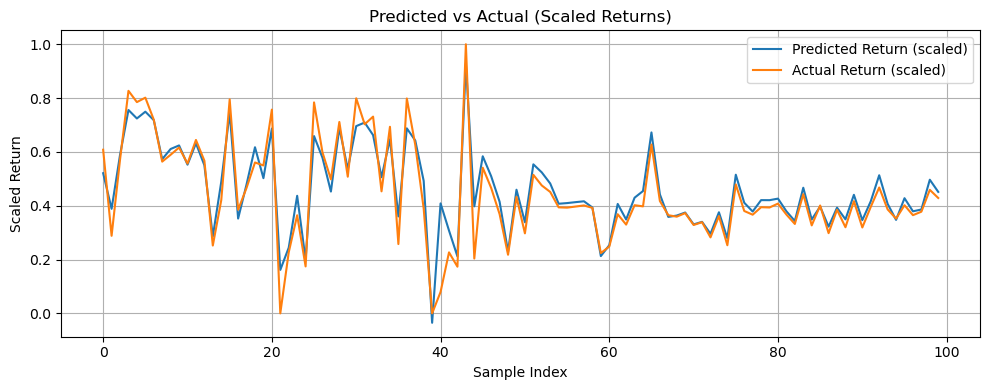

In [ ]:
best_row = wfv.iloc[wfv["r2"].idxmax()] # type: ignore
WIN      = int(best_row["window"])

best_model = LSTMModel(len(feature_cols),
                       hidden_dim=int(best_row["hidden_dim"]),
                       dropout=DROPOUT).to(device)
best_model.load_state_dict(best_row["model_state"])
best_model.eval()

# ---- hold-out slice
X_hold = X_all[-TEST_SIZE:] 
y_hold = y_all[-TEST_SIZE:]

with torch.no_grad():
    preds_hold = best_model(torch.tensor(X_hold).float().to(device)).cpu().numpy().ravel()

print(f"\nHold-out R² {r2_score(y_hold, preds_hold):.3f}")

# Plot Predicted vs Actual for Holdout Set
df_result = pd.DataFrame({
    "Predicted Return (scaled)": preds_hold,
    "Actual Return (scaled)": y_hold})

df_result.plot(figsize=(10, 4), title="Predicted vs Actual (Scaled Returns)")
plt.xlabel("Sample Index")
plt.ylabel("Scaled Return")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
torch.save({
    "model_state":  best_row["model_state"],
    "hidden_dim":   int(best_row["hidden_dim"]),
    "num_layers":   2,
    "feature_order":feature_cols,
    "window":       WIN
}, "lstm_best.pth")
print("saved lstm_best.pth")


saved lstm_best.pth


5-day forecast (scaled): [0.4513 0.4969 0.4397 0.4327 0.4478]
5-day forecast (% returns): [1.8447 2.9647 1.5595 1.3879 1.7594]


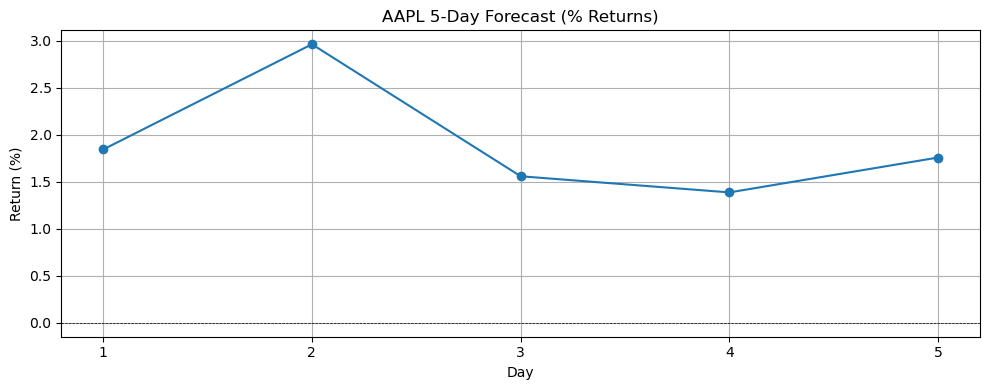

In [9]:
forecastDays = 5

def forecast_future_scaled(net, last_win_scaled, horizon):
    """
    Generate `horizon` future predictions in scaled space.
    """
    win   = last_win_scaled.copy()
    preds = []
    for _ in range(horizon):
        p = net(torch.tensor(win)
                   .float()
                   .unsqueeze(0)
                   .to(device)
               ).item()
        preds.append(p)
        new_row    = win[-1].copy()
        new_row[-1] = p
        win         = np.vstack([win[1:], new_row])
    return np.array(preds)

last_window_scaled = X_all[-1]

forecast_scaled = forecast_future_scaled(best_model, last_window_scaled, forecastDays)
print(f"{forecastDays}-day forecast (scaled):", np.round(forecast_scaled, 4))

q_last        = str(df_scaled.index[-1].to_period("Q"))
mms           = scalers_q[q_last]
scale, minv   = mms.data_max_[-1] - mms.data_min_[-1], mms.data_min_[-1]
forecast_raw  = forecast_scaled * scale + minv
forecast_pct  = forecast_raw * 100
print(f"{forecastDays}-day forecast (% returns):", np.round(forecast_pct, 4))

days = np.arange(1, forecastDays + 1)

plt.figure(figsize=(10, 4))
plt.plot(days, forecast_pct, marker='o', linestyle='-')
plt.title(f"{TICKER} {forecastDays}-Day Forecast (% Returns)")
plt.xlabel("Day")
plt.ylabel("Return (%)")
plt.xticks(days)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.grid(True)
plt.tight_layout()
plt.show()